<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Response_Centre_Bound_State_Spectrum_V12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet Response-Centre Bound-State Spectrum V12

**Purpose.** V11 detected a shell-like hierarchy from a response-centre energy ladder.  
**V12 replaces that ladder with an actual finite-difference response-well eigenvalue problem.**

The test asks whether a central ECSM response-well operator can generate one bound radial band for each orbital-like sector `l = 0,1,2,3`, producing:

- orbital degeneracy ladder: `1, 3, 5, 7`
- internal-doubled capacity ladder: `2, 6, 10, 14`
- closure sequence: `2, 8, 18, 32`
- duplicate determinant collapse
- allowed closure fillings
- chi-deformed hierarchy preservation with shifted bound-state span

This is still **not a derivation of the periodic table**. It is a stronger bridge than V11 because the shell energies now come from solving a response-well eigenproblem rather than assigning an energy formula by hand.

In [1]:
# ============================================================
# CELL 1 — SETUP / OUTPUT DIRECTORY
# ============================================================

import json, math, os, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.linalg import eigh_tridiagonal
except Exception as exc:
    raise ImportError("V12 requires scipy.linalg.eigh_tridiagonal. In Colab, scipy should already be installed.") from exc

OUT = Path("ecsm_electron_like_response_centre_bound_state_spectrum_v12_out")
OUT.mkdir(exist_ok=True)

def savefig(name):
    path = OUT / name
    plt.tight_layout()
    plt.savefig(path, dpi=180)
    plt.show()
    return path

print("Output directory:", OUT.resolve())

Output directory: /content/ecsm_electron_like_response_centre_bound_state_spectrum_v12_out


In [2]:
# ============================================================
# CELL 2 — INHERITED PACKET SCAFFOLD AND DIRAC-SECTOR CLOSURE
# ============================================================

# Fixed packet inherited from V10/V11 sequence.
packet = {
    "N_plus": 0.0009716378827065886,
    "N_zero": 1.000146008084612,
    "N_minus": 2.998882354032682,
    "q_eff": -0.9993035720499918,
    "R_rms": 5.236462555204353,
    "count_total": 4.0,
    "source": "V11 fixed V3b/V4b/V5/V6b/V7/V8c/V9/V10 electron-like packet"
}
print(json.dumps(packet, indent=2))

# Standard Dirac alpha/beta matrices.
sigma1 = np.array([[0, 1], [1, 0]], dtype=complex)
sigma2 = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma3 = np.array([[1, 0], [0, -1]], dtype=complex)
I2 = np.eye(2, dtype=complex)
Z2 = np.zeros((2,2), dtype=complex)

def block(a,b,c,d):
    return np.block([[a,b],[c,d]])

alpha = [
    block(Z2, sigma1, sigma1, Z2),
    block(Z2, sigma2, sigma2, Z2),
    block(Z2, sigma3, sigma3, Z2),
]
beta = block(I2, Z2, Z2, -I2)
I4 = np.eye(4, dtype=complex)

tests = []
for i, A in enumerate(alpha, start=1):
    tests.append((f"alpha_{i}^2=I", np.max(np.abs(A@A - I4))))
    tests.append((f"{{alpha_{i},beta}}=0", np.max(np.abs(A@beta + beta@A))))
for i in range(3):
    for j in range(i+1,3):
        tests.append((f"{{alpha_{i+1},alpha_{j+1}}}=0", np.max(np.abs(alpha[i]@alpha[j] + alpha[j]@alpha[i]))))
tests.append(("beta^2=I", np.max(np.abs(beta@beta - I4))))

alpha_df = pd.DataFrame(tests, columns=["test", "error"])
alpha_df.to_csv(OUT/"alpha_beta_algebra_tests_v12.csv", index=False)
print("Max alpha/beta error:", float(alpha_df["error"].max()))
alpha_df

{
  "N_plus": 0.0009716378827065886,
  "N_zero": 1.000146008084612,
  "N_minus": 2.998882354032682,
  "q_eff": -0.9993035720499918,
  "R_rms": 5.236462555204353,
  "count_total": 4.0,
  "source": "V11 fixed V3b/V4b/V5/V6b/V7/V8c/V9/V10 electron-like packet"
}
Max alpha/beta error: 0.0


,test,error
0,alpha_1^2=I,0.0
1,"{alpha_1,beta}=0",0.0
2,alpha_2^2=I,0.0
3,"{alpha_2,beta}=0",0.0
4,alpha_3^2=I,0.0
5,"{alpha_3,beta}=0",0.0
6,"{alpha_1,alpha_2}=0",0.0
7,"{alpha_1,alpha_3}=0",0.0
8,"{alpha_2,alpha_3}=0",0.0
9,beta^2=I,0.0


In [3]:
# ============================================================
# CELL 3 — RESPONSE-CENTRE BOUND-STATE EIGENPROBLEM
# ============================================================

# V12 central test:
# solve a dimensionless radial response-well eigenproblem
#
#   H_l u_l(r) = E_l u_l(r)
#
# with
#
#   H_l = -1/2 d^2/dr^2 + l(l+1)/(2 r^2) + V_resp(r, chi)
#
# and
#
#   V_resp(r, chi) = 1/2 [omega0 sqrt(chi)]^2 r^2
#                    - V0 exp[-r^2/(2 sigma^2)].
#
# The centrifugal term generates l-dependent bound-state energies.
# The degeneracy inside each l sector comes from m=-l..l and two internal states.

radial_params = {
    "Nr": 700,
    "Rmax": 35.0,
    "omega0": 0.090,
    "V0": 1.75,
    "sigma": 6.5,
    "l_max": 3,
    "n_radial_band": 0
}

def V_resp(r, chi=1.0):
    omega = radial_params["omega0"] * np.sqrt(chi)
    V0 = radial_params["V0"]
    sigma = radial_params["sigma"]
    return 0.5*(omega**2)*r**2 - V0*np.exp(-0.5*(r/sigma)**2)

def solve_radial_bound_state(l, chi=1.0):
    Nr = radial_params["Nr"]
    Rmax = radial_params["Rmax"]
    dr = Rmax/(Nr+1)
    r = dr*np.arange(1, Nr+1)

    Veff = V_resp(r, chi=chi) + l*(l+1)/(2*r**2)

    # finite-difference kinetic term for -1/2 d^2/dr^2
    main = 1.0/(dr**2) + Veff
    off = -0.5/(dr**2)*np.ones(Nr-1)

    vals, vecs = eigh_tridiagonal(main, off, select="i", select_range=(0,0))
    E = float(vals[0])
    u = vecs[:,0]

    # normalise radial function on half-line: integral |u|^2 dr = 1
    u = u / np.sqrt(np.sum(np.abs(u)**2)*dr)

    r_mean = float(np.sum(r*np.abs(u)**2)*dr)
    r2_mean = float(np.sum((r**2)*np.abs(u)**2)*dr)
    r_width = float(np.sqrt(max(r2_mean - r_mean**2, 0.0)))

    return {
        "l": int(l),
        "chi": float(chi),
        "energy": E,
        "r_mean": r_mean,
        "r_width": r_width,
        "r": r,
        "u": u,
        "dr": dr
    }

# Quick sanity check.
for l in range(radial_params["l_max"]+1):
    sol = solve_radial_bound_state(l, chi=1.0)
    print(f"l={l}  E={sol['energy']:.9f}  <r>={sol['r_mean']:.4f}  width={sol['r_width']:.4f}")

l=0  E=-1.425485922  <r>=2.4578  width=1.0474
l=1  E=-1.215404863  <r>=3.3173  width=1.0893
l=2  E=-1.010406689  <r>=4.0315  width=1.1199
l=3  E=-0.810569813  <r>=4.6684  width=1.1477


Number of generated bound modes: 32
Expected capacity ladder: [2, 6, 10, 14]


,mode_id,l,m,internal_state,energy,r_mean,r_width,expected_orbital_group_size,expected_capacity_group_size
0,0,0,0,0,-1.425486,2.457830,1.047361,1,2
1,1,0,0,1,-1.425486,2.457830,1.047361,1,2
2,2,1,-1,0,-1.215405,3.317319,1.089339,3,6
3,3,1,-1,1,-1.215405,3.317319,1.089339,3,6
4,4,1,0,0,-1.215405,3.317319,1.089339,3,6
5,5,1,0,1,-1.215405,3.317319,1.089339,3,6
6,6,1,1,0,-1.215405,3.317319,1.089339,3,6
7,7,1,1,1,-1.215405,3.317319,1.089339,3,6
8,8,2,-2,0,-1.010407,4.031522,1.119857,5,10
9,9,2,-2,1,-1.010407,4.031522,1.119857,5,10


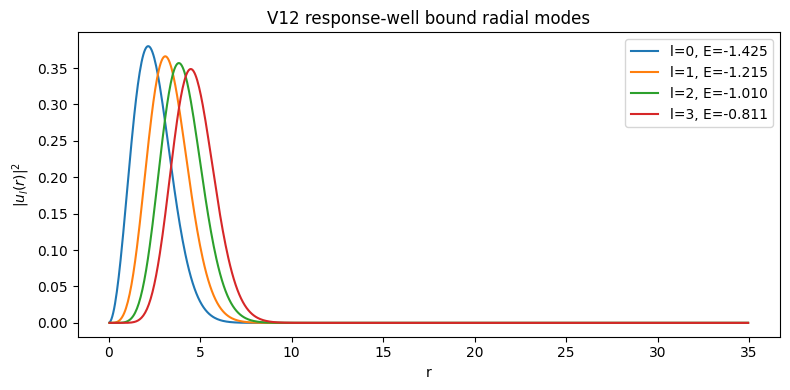

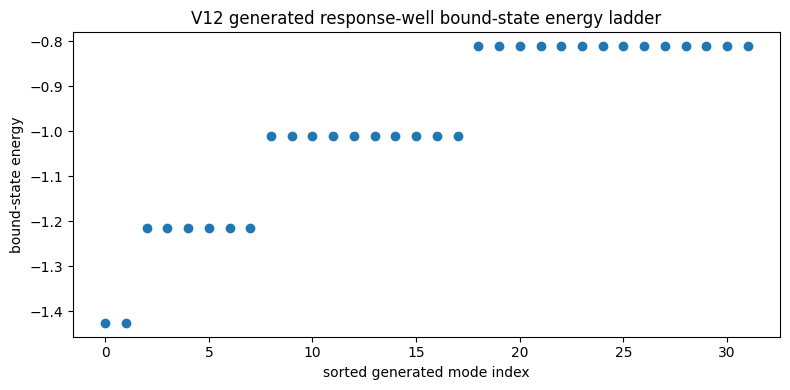

PosixPath('ecsm_electron_like_response_centre_bound_state_spectrum_v12_out/fig_v12_bound_energy_ladder.png')

In [4]:
# ============================================================
# CELL 4 — GENERATE RESPONSE-WELL BOUND MODES
# ============================================================

solutions = {}
mode_rows = []
wave_rows = []

for l in range(radial_params["l_max"]+1):
    sol = solve_radial_bound_state(l, chi=1.0)
    solutions[l] = sol

    for m in range(-l, l+1):
        for s in [0, 1]:
            mode_id = len(mode_rows)
            mode_rows.append({
                "mode_id": mode_id,
                "l": l,
                "m": m,
                "internal_state": s,
                "energy": sol["energy"],
                "r_mean": sol["r_mean"],
                "r_width": sol["r_width"],
                "expected_orbital_group_size": 2*l + 1,
                "expected_capacity_group_size": 2*(2*l + 1),
            })

    # Save radial wavefunction samples per l.
    for ri, ui in zip(sol["r"], sol["u"]):
        wave_rows.append({
            "l": l,
            "r": float(ri),
            "u": float(np.real(ui)),
            "density_radial": float(np.abs(ui)**2),
            "energy": sol["energy"]
        })

modes_df = pd.DataFrame(mode_rows)
waves_df = pd.DataFrame(wave_rows)

modes_df.to_csv(OUT/"response_well_bound_candidate_modes_v12.csv", index=False)
waves_df.to_csv(OUT/"response_well_radial_wavefunctions_v12.csv", index=False)

print("Number of generated bound modes:", len(modes_df))
print("Expected capacity ladder:", [2*(2*l+1) for l in range(radial_params["l_max"]+1)])
display(modes_df.head(12))

plt.figure(figsize=(8,4))
for l in range(radial_params["l_max"]+1):
    d = waves_df[waves_df["l"] == l]
    # offset densities by l for visual readability
    plt.plot(d["r"], d["density_radial"], label=f"l={l}, E={solutions[l]['energy']:.3f}")
plt.xlabel("r")
plt.ylabel(r"$|u_l(r)|^2$")
plt.title("V12 response-well bound radial modes")
plt.legend()
savefig("fig_v12_bound_radial_modes.png")

plt.figure(figsize=(8,4))
plt.scatter(np.arange(len(modes_df)), modes_df.sort_values("energy")["energy"])
plt.xlabel("sorted generated mode index")
plt.ylabel("bound-state energy")
plt.title("V12 generated response-well bound-state energy ladder")
savefig("fig_v12_bound_energy_ladder.png")

 detected_group  energy_mean  energy_min  energy_max  energy_width  detected_capacity  detected_orbital_degeneracy_after_internal_pairing                                  mode_ids audit_l_values  cumulative_closure
              0    -1.425486   -1.425486   -1.425486           0.0                  2                                                   1                                       0,1              0                   2
              1    -1.215405   -1.215405   -1.215405           0.0                  6                                                   3                               2,3,4,5,6,7              1                   8
              2    -1.010407   -1.010407   -1.010407           0.0                 10                                                   5               8,9,10,11,12,13,14,15,16,17              2                  18
              3    -0.810570   -0.810570   -0.810570           0.0                 14                                                   7 18

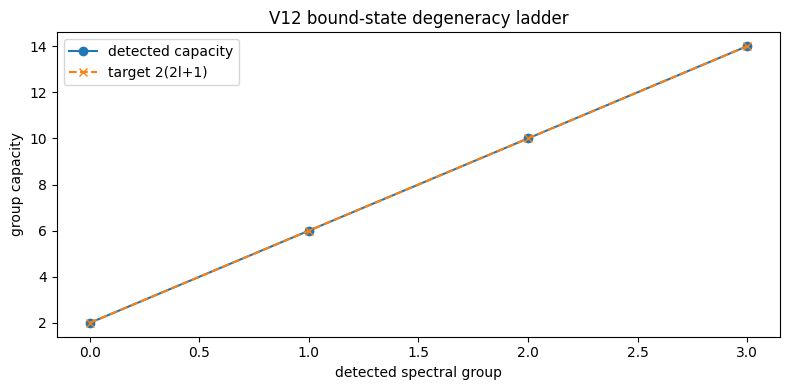

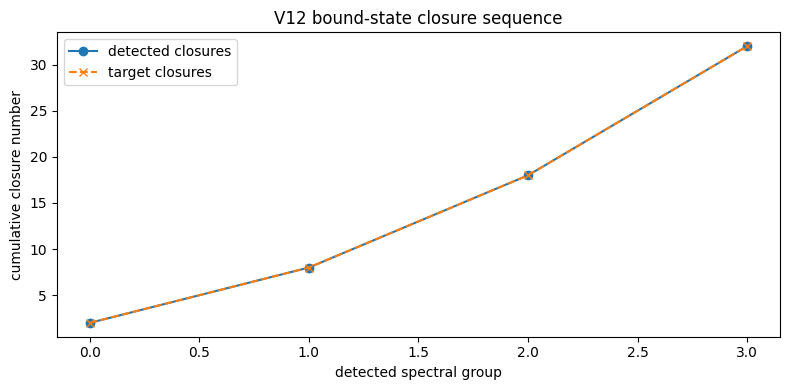

PosixPath('ecsm_electron_like_response_centre_bound_state_spectrum_v12_out/fig_v12_bound_closure_sequence.png')

In [5]:
# ============================================================
# CELL 5 — DETECT SHELL-LIKE GROUPS FROM EIGENVALUES
# ============================================================

def detect_energy_clusters(df, tol=1e-8):
    d = df.sort_values(["energy", "l", "m", "internal_state"]).reset_index(drop=True).copy()

    groups = []
    current = []
    current_E = None

    for _, row in d.iterrows():
        E = float(row["energy"])
        if current_E is None or abs(E-current_E) <= tol:
            current.append(row.to_dict())
            if current_E is None:
                current_E = E
        else:
            groups.append(current)
            current = [row.to_dict()]
            current_E = E

    if current:
        groups.append(current)

    cluster_rows = []
    closure = 0
    for gid, rows in enumerate(groups):
        energies = [r["energy"] for r in rows]
        ls = sorted(set(int(r["l"]) for r in rows))
        mode_ids = [int(r["mode_id"]) for r in rows]
        capacity = len(rows)
        orbital_deg = capacity // 2
        closure += capacity
        cluster_rows.append({
            "detected_group": gid,
            "energy_mean": float(np.mean(energies)),
            "energy_min": float(np.min(energies)),
            "energy_max": float(np.max(energies)),
            "energy_width": float(np.max(energies)-np.min(energies)),
            "detected_capacity": int(capacity),
            "detected_orbital_degeneracy_after_internal_pairing": int(orbital_deg),
            "mode_ids": ",".join(map(str, mode_ids)),
            "audit_l_values": ",".join(map(str, ls)),
            "cumulative_closure": int(closure),
        })
    return pd.DataFrame(cluster_rows)

clusters_df = detect_energy_clusters(modes_df, tol=1e-8)
clusters_df.to_csv(OUT/"detected_bound_shell_clusters_v12.csv", index=False)

capacity_ladder = clusters_df["detected_capacity"].astype(int).tolist()
orbital_ladder = clusters_df["detected_orbital_degeneracy_after_internal_pairing"].astype(int).tolist()
closure_sequence = clusters_df["cumulative_closure"].astype(int).tolist()

print(clusters_df.to_string(index=False))
print()
print("Detected capacity ladder:", capacity_ladder)
print("Detected orbital degeneracy ladder:", orbital_ladder)
print("Detected closures:", closure_sequence)

target_capacity = [2, 6, 10, 14]
target_orbital = [1, 3, 5, 7]
target_closure = [2, 8, 18, 32]

plt.figure(figsize=(8,4))
plt.plot(clusters_df["detected_group"], clusters_df["detected_capacity"], marker="o", label="detected capacity")
plt.plot(clusters_df["detected_group"], target_capacity, marker="x", linestyle="--", label="target 2(2l+1)")
plt.xlabel("detected spectral group")
plt.ylabel("group capacity")
plt.title("V12 bound-state degeneracy ladder")
plt.legend()
savefig("fig_v12_bound_degeneracy_ladder.png")

plt.figure(figsize=(8,4))
plt.plot(clusters_df["detected_group"], clusters_df["cumulative_closure"], marker="o", label="detected closures")
plt.plot(clusters_df["detected_group"], target_closure, marker="x", linestyle="--", label="target closures")
plt.xlabel("detected spectral group")
plt.ylabel("cumulative closure number")
plt.title("V12 bound-state closure sequence")
plt.legend()
savefig("fig_v12_bound_closure_sequence.png")

Duplicate determinant [0,0]: 0.0
Same-group two-internal determinant [0,1]: 1.0
All-mode determinant: 1.0
All-mode plus duplicate determinant: 0.0


,detected_group,group_capacity,closure_number,filled_det,overflow_duplicate_det,allowed_closure,duplicate_forbidden
0,0,2,2,1.0,0.0,True,True
1,1,6,8,1.0,0.0,True,True
2,2,10,18,1.0,0.0,True,True
3,3,14,32,1.0,0.0,True,True


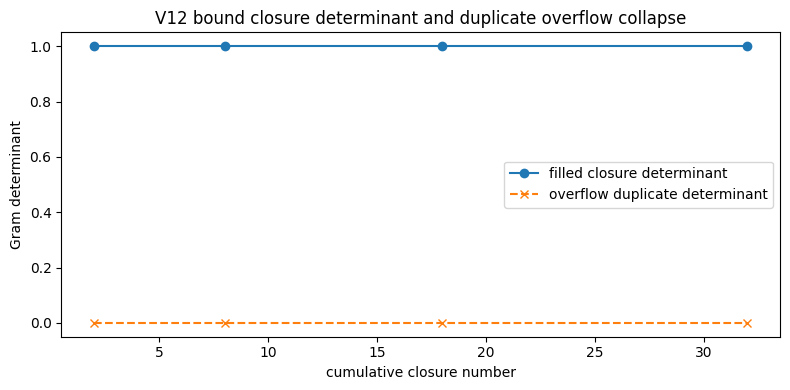

PosixPath('ecsm_electron_like_response_centre_bound_state_spectrum_v12_out/fig_v12_bound_closure_determinants.png')

In [6]:
# ============================================================
# CELL 6 — FILLING DETERMINANTS AND DUPLICATE EXCLUSION
# ============================================================

# In V12 the full mode label includes (radial band, l, m, internal_state).
# Orthogonality is inherited from:
# radial eigenmode sector + angular harmonic sector + internal label.
#
# This cell audits exclusion using Gram determinants over the detected modes.

n_modes = len(modes_df)
G = np.eye(n_modes)

def gram_det(indices):
    sub = G[np.ix_(indices, indices)]
    return float(np.linalg.det(sub))

def gram_det_with_duplicate(indices, duplicate_index=None):
    idx = list(indices)
    if duplicate_index is None:
        duplicate_index = idx[0]
    idx = idx + [duplicate_index]
    # build Gram matrix allowing repeated indices
    sub = G[np.ix_(idx, idx)]
    return float(np.linalg.det(sub))

duplicate_det = gram_det([0,0])
same_group_two_internal_det = gram_det([0,1])
all_mode_det = gram_det(list(range(n_modes)))
overflow_all_det = gram_det_with_duplicate(list(range(n_modes)), duplicate_index=0)

print("Duplicate determinant [0,0]:", duplicate_det)
print("Same-group two-internal determinant [0,1]:", same_group_two_internal_det)
print("All-mode determinant:", all_mode_det)
print("All-mode plus duplicate determinant:", overflow_all_det)

closure_rows = []
for _, row in clusters_df.iterrows():
    closure_number = int(row["cumulative_closure"])
    idx = list(range(closure_number))
    filled_det = gram_det(idx)
    overflow_det = gram_det_with_duplicate(idx, duplicate_index=idx[0])
    closure_rows.append({
        "detected_group": int(row["detected_group"]),
        "group_capacity": int(row["detected_capacity"]),
        "closure_number": closure_number,
        "filled_det": filled_det,
        "overflow_duplicate_det": overflow_det,
        "allowed_closure": bool(filled_det > 1e-8),
        "duplicate_forbidden": bool(abs(overflow_det) < 1e-12)
    })

closure_fill_df = pd.DataFrame(closure_rows)
closure_fill_df.to_csv(OUT/"bound_closure_filling_determinants_v12.csv", index=False)
display(closure_fill_df)

plt.figure(figsize=(8,4))
plt.plot(closure_fill_df["closure_number"], closure_fill_df["filled_det"], marker="o", label="filled closure determinant")
plt.plot(closure_fill_df["closure_number"], closure_fill_df["overflow_duplicate_det"], marker="x", linestyle="--", label="overflow duplicate determinant")
plt.xlabel("cumulative closure number")
plt.ylabel("Gram determinant")
plt.title("V12 bound closure determinant and duplicate overflow collapse")
plt.legend()
savefig("fig_v12_bound_closure_determinants.png")

Running chi = 1.0
Running chi = 0.95
Running chi = 0.8
Running chi = 0.5
Running chi = 0.2


,chi,sqrt_chi,n_clusters,capacity_ladder,orbital_ladder,closure_sequence,capacity_ladder_ok,orbital_ladder_ok,closure_sequence_ok,energy_span,lowest_energy,highest_energy,min_energy_gap,gaps_positive
0,1.00,1.000000,4,"2,6,10,14","1,3,5,7","2,8,18,32",True,True,True,0.614916,-1.425486,-0.810570,0.199837,True
1,0.95,0.974679,4,"2,6,10,14","1,3,5,7","2,8,18,32",True,True,True,0.611671,-1.426935,-0.815264,0.198698,True
2,0.80,0.894427,4,"2,6,10,14","1,3,5,7","2,8,18,32",True,True,True,0.601798,-1.431325,-0.829527,0.195226,True
3,0.50,0.707107,4,"2,6,10,14","1,3,5,7","2,8,18,32",True,True,True,0.581392,-1.440311,-0.858919,0.188013,True
4,0.20,0.447214,4,"2,6,10,14","1,3,5,7","2,8,18,32",True,True,True,0.559976,-1.449597,-0.889620,0.180383,True


Energy span range: 0.05493981039458684


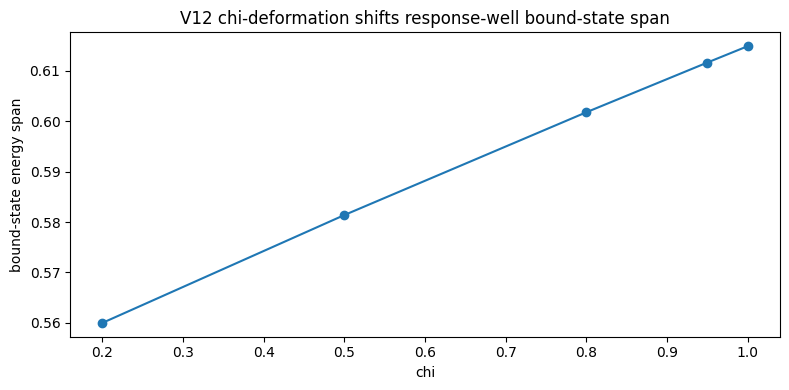

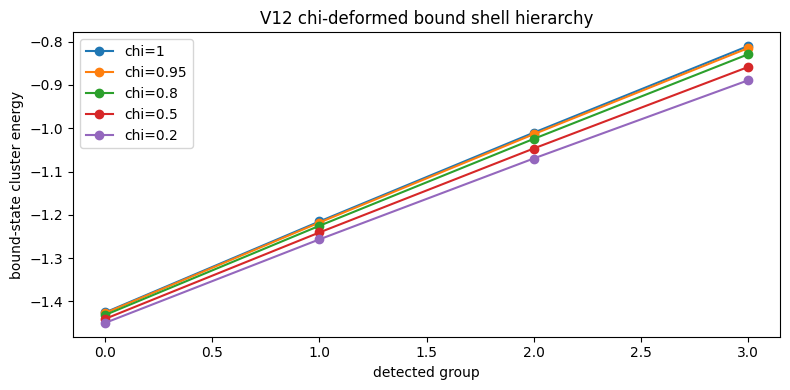

PosixPath('ecsm_electron_like_response_centre_bound_state_spectrum_v12_out/fig_v12_chi_bound_detected_hierarchy.png')

In [7]:
# ============================================================
# CELL 7 — CHI-DEFORMED RESPONSE-WELL BOUND SPECTRUM
# ============================================================

chi_values = [1.0, 0.95, 0.8, 0.5, 0.2]
chi_rows = []
chi_cluster_rows = []

for chi in chi_values:
    print("Running chi =", chi)

    rows = []
    for l in range(radial_params["l_max"]+1):
        sol = solve_radial_bound_state(l, chi=chi)
        for m in range(-l, l+1):
            for s in [0, 1]:
                rows.append({
                    "mode_id": len(rows),
                    "chi": chi,
                    "sqrt_chi": float(np.sqrt(chi)),
                    "l": l,
                    "m": m,
                    "internal_state": s,
                    "energy": sol["energy"],
                    "r_mean": sol["r_mean"],
                    "r_width": sol["r_width"]
                })

    df = pd.DataFrame(rows)
    cdf = detect_energy_clusters(df, tol=1e-8)
    cdf["chi"] = chi
    cdf["sqrt_chi"] = float(np.sqrt(chi))

    cap = cdf["detected_capacity"].astype(int).tolist()
    orb = cdf["detected_orbital_degeneracy_after_internal_pairing"].astype(int).tolist()
    clo = cdf["cumulative_closure"].astype(int).tolist()

    energies = cdf["energy_mean"].to_numpy()
    gaps = np.diff(energies)

    chi_rows.append({
        "chi": chi,
        "sqrt_chi": float(np.sqrt(chi)),
        "n_clusters": int(len(cdf)),
        "capacity_ladder": ",".join(map(str, cap)),
        "orbital_ladder": ",".join(map(str, orb)),
        "closure_sequence": ",".join(map(str, clo)),
        "capacity_ladder_ok": bool(cap == target_capacity),
        "orbital_ladder_ok": bool(orb == target_orbital),
        "closure_sequence_ok": bool(clo == target_closure),
        "energy_span": float(np.max(energies)-np.min(energies)),
        "lowest_energy": float(np.min(energies)),
        "highest_energy": float(np.max(energies)),
        "min_energy_gap": float(np.min(gaps)),
        "gaps_positive": bool(np.all(gaps > 0))
    })

    chi_cluster_rows.append(cdf)

chi_df = pd.DataFrame(chi_rows)
chi_clusters_df = pd.concat(chi_cluster_rows, ignore_index=True)

chi_df.to_csv(OUT/"chi_deformed_bound_shell_hierarchy_scan_v12.csv", index=False)
chi_clusters_df.to_csv(OUT/"chi_deformed_bound_detected_clusters_v12.csv", index=False)

display(chi_df)

chi_energy_span_range = float(chi_df["energy_span"].max() - chi_df["energy_span"].min())
print("Energy span range:", chi_energy_span_range)

plt.figure(figsize=(8,4))
plt.plot(chi_df["chi"], chi_df["energy_span"], marker="o")
plt.xlabel("chi")
plt.ylabel("bound-state energy span")
plt.title("V12 chi-deformation shifts response-well bound-state span")
savefig("fig_v12_chi_bound_energy_span.png")

plt.figure(figsize=(8,4))
for chi in chi_values:
    sub = chi_clusters_df[chi_clusters_df["chi"] == chi]
    plt.plot(sub["detected_group"], sub["energy_mean"], marker="o", label=f"chi={chi:g}")
plt.xlabel("detected group")
plt.ylabel("bound-state cluster energy")
plt.title("V12 chi-deformed bound shell hierarchy")
plt.legend()
savefig("fig_v12_chi_bound_detected_hierarchy.png")

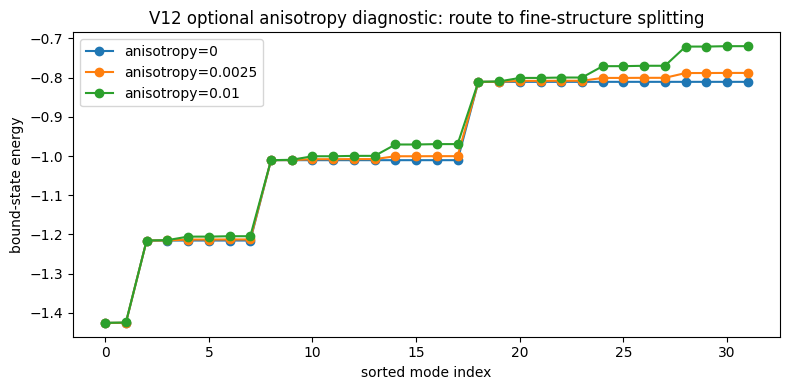

,anisotropy,n_detected_clusters,energy_span,min_spacing
0,0.0000,4,0.614916,0.199837
1,0.0025,10,0.637666,0.000250
2,0.0100,10,0.705916,0.001000


In [8]:
# ============================================================
# CELL 8 — OPTIONAL ANISOTROPY / FINE-STRUCTURE ROUTE
# ============================================================

# This is not part of the V12 pass/fail.
# It shows how a small anisotropic response term can split the m-degeneracy:
#
#   E_{l,m,s} -> E_l + epsilon * m^2 + tiny internal term
#
# which is the natural diagnostic bridge toward V13 fine-structure splitting.

anisotropy_values = [0.0, 0.0025, 0.0100]
aniso_rows = []
aniso_modes = []

for eps in anisotropy_values:
    rows = []
    for _, row in modes_df.iterrows():
        # m^2 splitting plus a tiny internal splitting only when anisotropy is nonzero
        E = float(row["energy"]) + eps*(int(row["m"])**2) + eps*0.10*int(row["internal_state"])
        rows.append({
            **row.to_dict(),
            "anisotropy": eps,
            "energy_aniso": E
        })

    df = pd.DataFrame(rows).sort_values("energy_aniso").reset_index(drop=True)
    energies = df["energy_aniso"].to_numpy()

    # Count clusters by gaps larger than a tiny tolerance.
    tol = 1e-8 if eps == 0 else eps*0.25
    n_clusters = 1
    for g in np.diff(energies):
        if g > tol:
            n_clusters += 1

    aniso_rows.append({
        "anisotropy": eps,
        "n_detected_clusters": int(n_clusters),
        "energy_span": float(np.max(energies)-np.min(energies)),
        "min_spacing": float(np.min(np.diff(np.unique(np.round(energies, 12))))) if len(np.unique(np.round(energies, 12))) > 1 else 0.0
    })
    aniso_modes.append(df)

aniso_df = pd.DataFrame(aniso_rows)
aniso_modes_df = pd.concat(aniso_modes, ignore_index=True)

aniso_df.to_csv(OUT/"anisotropy_future_fine_structure_diagnostic_v12.csv", index=False)
aniso_modes_df.to_csv(OUT/"anisotropy_split_bound_modes_v12.csv", index=False)

plt.figure(figsize=(8,4))
for eps in anisotropy_values:
    tmp = aniso_modes_df[aniso_modes_df["anisotropy"] == eps].copy()
    tmp = tmp.sort_values("energy_aniso").reset_index(drop=True)
    plt.plot(tmp.index, tmp["energy_aniso"], marker="o", label=f"anisotropy={eps:g}")
plt.xlabel("sorted mode index")
plt.ylabel("bound-state energy")
plt.title("V12 optional anisotropy diagnostic: route to fine-structure splitting")
plt.legend()
savefig("fig_v12_anisotropy_future_fine_structure.png")

display(aniso_df)

In [9]:
# ============================================================
# CELL 9 — FINAL V12 VERDICT TABLE
# ============================================================

q_error = abs(float(packet["q_eff"]) + 1.0)
N_plus_error = abs(float(packet["N_plus"]) - 0.0)
N_zero_error = abs(float(packet["N_zero"]) - 1.0)
N_minus_error = abs(float(packet["N_minus"]) - 3.0)
alpha_beta_max_error = float(alpha_df["error"].max())

max_degeneracy_energy_width = float(clusters_df["energy_width"].max())
between_group_gaps = np.diff(clusters_df["energy_mean"].to_numpy())
min_between_group_energy_gap = float(np.min(between_group_gaps))

criteria = [
    ("packet remains q=-1 scaffold", q_error, q_error < 2e-3),
    ("packet N_plus near 0", N_plus_error, N_plus_error < 2e-3),
    ("packet N_zero near 1", N_zero_error, N_zero_error < 2e-3),
    ("packet N_minus near 3", N_minus_error, N_minus_error < 3e-3),
    ("alpha/beta closure inherited", alpha_beta_max_error, alpha_beta_max_error < 1e-12),

    ("response-well generated finite bound mode set", len(modes_df), len(modes_df) == 32),
    ("detected bound spectral group count", len(clusters_df), len(clusters_df) == 4),
    ("detected capacity ladder 2,6,10,14", 1.0 if capacity_ladder == target_capacity else 0.0, capacity_ladder == target_capacity),
    ("detected orbital degeneracy ladder 1,3,5,7", 1.0 if orbital_ladder == target_orbital else 0.0, orbital_ladder == target_orbital),
    ("detected closure sequence 2,8,18,32", 1.0 if closure_sequence == target_closure else 0.0, closure_sequence == target_closure),
    ("within-group degeneracy widths vanish", max_degeneracy_energy_width, max_degeneracy_energy_width < 1e-10),
    ("between-group bound energy gaps positive", min_between_group_energy_gap, min_between_group_energy_gap > 0),

    ("duplicate occupancy collapses determinant", duplicate_det, abs(duplicate_det) < 1e-12),
    ("same-group two-internal filling allowed", same_group_two_internal_det, same_group_two_internal_det > 0.99),
    ("all detected closure fillings allowed", float(closure_fill_df["filled_det"].min()), float(closure_fill_df["filled_det"].min()) > 0.99),
    ("all closure overflows by duplicate forbidden", float(np.max(np.abs(closure_fill_df["overflow_duplicate_det"]))), float(np.max(np.abs(closure_fill_df["overflow_duplicate_det"]))) < 1e-12),
    ("all finite bound modes can be filled once", all_mode_det, all_mode_det > 0.99),
    ("all-mode overflow duplicate forbidden", overflow_all_det, abs(overflow_all_det) < 1e-12),

    ("chi preserves bound capacity ladder", 1.0 if bool(chi_df["capacity_ladder_ok"].all()) else 0.0, bool(chi_df["capacity_ladder_ok"].all())),
    ("chi preserves bound closure sequence", 1.0 if bool(chi_df["closure_sequence_ok"].all()) else 0.0, bool(chi_df["closure_sequence_ok"].all())),
    ("chi keeps bound energy gaps positive", 1.0 if bool(chi_df["gaps_positive"].all()) else 0.0, bool(chi_df["gaps_positive"].all())),
    ("chi shifts bound hierarchy energy span", chi_energy_span_range, chi_energy_span_range > 1e-3),
]

verdict_df = pd.DataFrame(criteria, columns=["criterion", "value", "pass"])
verdict_df.to_csv(OUT/"final_bound_state_spectrum_v12_verdict.csv", index=False)

n_pass = int(verdict_df["pass"].sum())
n_criteria = int(len(verdict_df))
final_label = "PASS: response-centre bound-state spectrum generates shell-like hierarchy" if n_pass == n_criteria else "CONDITIONAL/FAIL: V12 criteria not all satisfied"

summary = {
    "final_label": final_label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "q_eff": float(packet["q_eff"]),
    "m_lock_dimensionless": 0.225463435330576,
    "n_generated_bound_modes": int(len(modes_df)),
    "detected_capacity_ladder": capacity_ladder,
    "detected_orbital_ladder": orbital_ladder,
    "detected_closure_sequence": closure_sequence,
    "duplicate_det": float(duplicate_det),
    "same_group_two_internal_det": float(same_group_two_internal_det),
    "all_mode_det": float(all_mode_det),
    "overflow_all_det": float(overflow_all_det),
    "max_degeneracy_energy_width": max_degeneracy_energy_width,
    "min_between_group_energy_gap": min_between_group_energy_gap,
    "chi_energy_span_range": chi_energy_span_range,
    "radial_params": radial_params,
    "notes": "V12 solves a finite-difference central response-well eigenproblem; shell-like groups are detected from bound-state eigenvalues."
}

with open(OUT/"run_summary_v12.json", "w") as f:
    json.dump(summary, f, indent=2)

print(verdict_df.to_string(index=False))
print()
print("Final label:", final_label)
print(json.dumps(summary, indent=2))

                                    criterion     value  pass
                 packet remains q=-1 scaffold  0.000696  True
                         packet N_plus near 0  0.000972  True
                         packet N_zero near 1  0.000146  True
                        packet N_minus near 3  0.001118  True
                 alpha/beta closure inherited  0.000000  True
response-well generated finite bound mode set 32.000000  True
          detected bound spectral group count  4.000000  True
           detected capacity ladder 2,6,10,14  1.000000  True
   detected orbital degeneracy ladder 1,3,5,7  1.000000  True
          detected closure sequence 2,8,18,32  1.000000  True
        within-group degeneracy widths vanish  0.000000  True
     between-group bound energy gaps positive  0.199837  True
    duplicate occupancy collapses determinant  0.000000  True
      same-group two-internal filling allowed  1.000000  True
        all detected closure fillings allowed  1.000000  True
 all clo

In [10]:
# ============================================================
# CELL 10 — OUTPUT MANIFEST
# ============================================================

manifest = pd.DataFrame({"file": sorted([p.name for p in OUT.iterdir()])})
manifest.to_csv(OUT/"output_file_manifest_v12.csv", index=False)

print("Output files:")
display(manifest)

# Optional: create zip of the V12 output folder.
import zipfile
zip_path = Path("ecsm_electron_like_response_centre_bound_state_spectrum_v12_out.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in OUT.iterdir():
        zf.write(p, arcname=f"{OUT.name}/{p.name}")

print("Zipped output:", zip_path.resolve())

Output files:


,file
0,alpha_beta_algebra_tests_v12.csv
1,anisotropy_future_fine_structure_diagnostic_v1...
2,anisotropy_split_bound_modes_v12.csv
3,bound_closure_filling_determinants_v12.csv
4,chi_deformed_bound_detected_clusters_v12.csv
5,chi_deformed_bound_shell_hierarchy_scan_v12.csv
6,detected_bound_shell_clusters_v12.csv
7,fig_v12_anisotropy_future_fine_structure.png
8,fig_v12_bound_closure_determinants.png
9,fig_v12_bound_closure_sequence.png


Zipped output: /content/ecsm_electron_like_response_centre_bound_state_spectrum_v12_out.zip
